In [104]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

In [105]:
raw_data = pd.read_csv("../Dataset/anti-malware .csv")
raw_data

,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
0,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,2,0,10,0,4,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,5,2,2,96,2,15,3,116,2,1,...,0,0,0,0,0,0,0,0,0,1
3,9,13,5,662,37,0,0,405,0,1,...,0,0,0,0,0,0,0,0,0,1
4,3,2,2,94,3,17,4,116,2,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11256,204,41,109,2680,77,102,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11257,197,39,107,2525,73,135,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11258,198,39,109,2534,72,162,22,188,0,11,...,0,0,0,0,0,0,0,0,0,1
11259,13,0,3,481,29,0,101,171,10,5,...,0,0,0,0,0,0,0,0,0,1


In [106]:
raw_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11261 entries, 0 to 11260
Data columns (total 312 columns):
 #    Column                             Dtype
---   ------                             -----
 0    NtDuplicateObject                  int64
 1    NtOpenSection                      int64
 2    CoUninitialize                     int64
 3    RegCloseKey                        int64
 4    LdrUnloadDll                       int64
 5    DrawTextExW                        int64
 6    GetSystemInfo                      int64
 7    RegQueryValueExA                   int64
 8    getaddrinfo                        int64
 9    WSAStartup                         int64
 10   GetSystemWindowsDirectoryW         int64
 11   NtClose                            int64
 12   GetFileVersionInfoSizeW            int64
 13   MessageBoxTimeoutA                 int64
 14   RegQueryValueExW                   int64
 15   NtOpenDirectoryObject              int64
 16   RegEnumKeyW                        int

In [107]:
non_num_cols = [c for c, dt in raw_data.dtypes.items()
                if not pd.api.types.is_numeric_dtype(dt)]
print(non_num_cols)

[]


all of the inputs are integer/numeric data type

In [108]:
raw_data.isnull().sum().max()

np.int64(0)

all the inputs are filled

In [109]:
X = raw_data.drop('OUTPUT', axis=1)
y = raw_data['OUTPUT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(9008, 311) (2253, 311) (9008,) (2253,)


In [110]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-0.03369857, -0.20766072, -0.11164974, ..., -0.01053683,
        -0.01098463, -0.02817047],
       [-0.03551405, -0.2465383 , -0.11164974, ..., -0.01053683,
        -0.01098463, -0.02817047],
       [-0.03551405, -0.2465383 , -0.11164974, ..., -0.01053683,
        -0.01098463, -0.02817047],
       ...,
       [ 0.01183976, -0.2465383 , -0.10673425, ..., -0.01053683,
        -0.01098463, -0.02817047],
       [-0.03415244, -0.2465383 , -0.11164974, ..., -0.01053683,
        -0.01098463, -0.02817047],
       [-0.03551405, -0.19470153, -0.10837275, ..., -0.01053683,
        -0.01098463, -0.02817047]], shape=(9008, 311))

data splitting ad scaling completed successfully

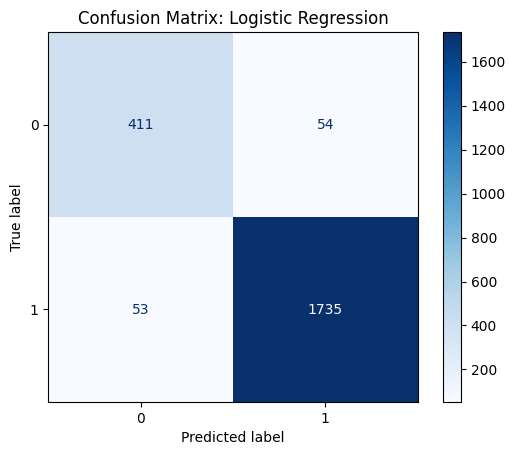

In [111]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test,y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

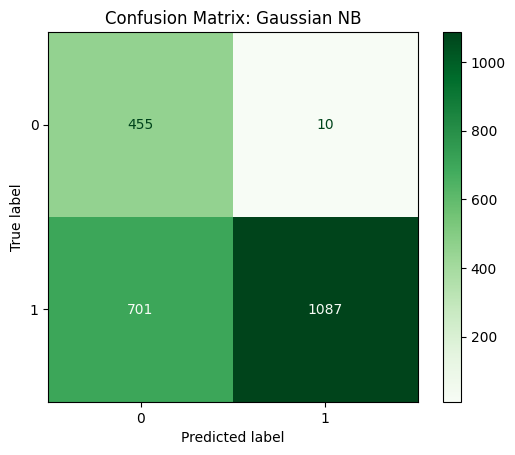

In [112]:
gnb = GaussianNB()
gnb.fit(X_train_scaled,y_train)

y_pred_gnb = gnb.predict(X_test_scaled)
cm_gnb = confusion_matrix(y_test,y_pred_gnb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gnb)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix: Gaussian NB")
plt.show()

In [113]:
acc_lr = accuracy_score(y_test,y_pred_lr)
acc_gnb = accuracy_score(y_test,y_pred_gnb)
print("acc_lr: ",acc_lr,"\nacc_gnb: ",acc_gnb)

acc_lr:  0.9525077674212161 
acc_gnb:  0.6844207723035952


### Based on Confusion Matrix, which model do better? explain.

Logistic Regression is far better than Gaussian naive bayes.
 - False Negative: in LR model there is just 53 cases are wrong but in GNB the number is 701 that is very bad in this senario because we're talking about bad malwares!
 - Accuracy: we can see the accuracy of the logistic regression is 95 percent and for gnb is 68 percent.
 - False Positive: in this senario 10 against 54 when the FN is far worst, is not matter!

Naive Bayes algorithm assumes that features are completely independent of one another. However, in malware data, features are typically interrelated. <br>
Since LR doesn't rely on this restrictive assumption, it is much better at learning the relationships between features.